In [4]:
#pip install tensorflow

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt



In [6]:
# Load the California Housing dataset
data = fetch_california_housing()
X, y = data.data, data.target



In [7]:
X.shape

(20640, 8)

In [8]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [9]:
# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [10]:
# Build a neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Regression output
])



C:\Users\cipl\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compile the model with SGD and Nesterov momentum
model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True), 
              loss='mse', 
              metrics=['mae'])



In [12]:
import time

In [13]:
# Train the model
start=time.time()
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, verbose=1)
print(time.time()-start)

Epoch 1/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7701 - mae: 0.6134 - val_loss: 0.4427 - val_mae: 0.4585
Epoch 2/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 16.9249 - mae: 0.8503 - val_loss: 1.2421 - val_mae: 0.8919
Epoch 3/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2355 - mae: 0.8686 - val_loss: 1.1535 - val_mae: 0.8423
Epoch 4/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1953 - mae: 0.8482 - val_loss: 1.3268 - val_mae: 0.9315
Epoch 5/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3562 - mae: 0.9213 - val_loss: 1.3105 - val_mae: 0.9044
Epoch 6/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3608 - mae: 0.9226 - val_loss: 1.3107 - val_mae: 0.9064
Epoch 7/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3515 - mae: 0.9189 - val_loss: 1.3186 - val_mae: 0.9222
Epoch 8/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3486 - mae: 0.9182 - val_loss: 1.3107 - val_mae: 0.8973
Epoch 9/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - l

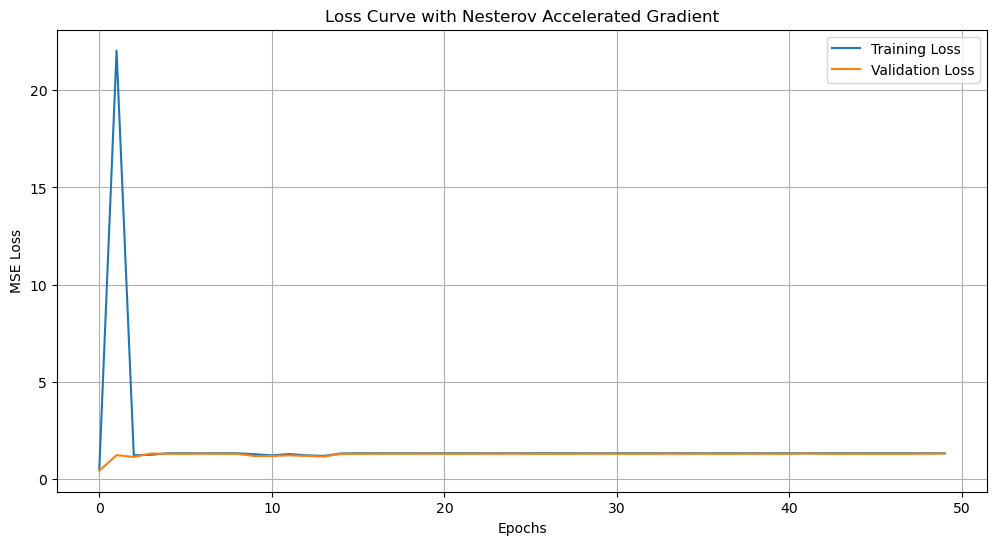

In [14]:
# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Loss Curve with Nesterov Accelerated Gradient')
plt.legend()
plt.grid(True)
plt.show()



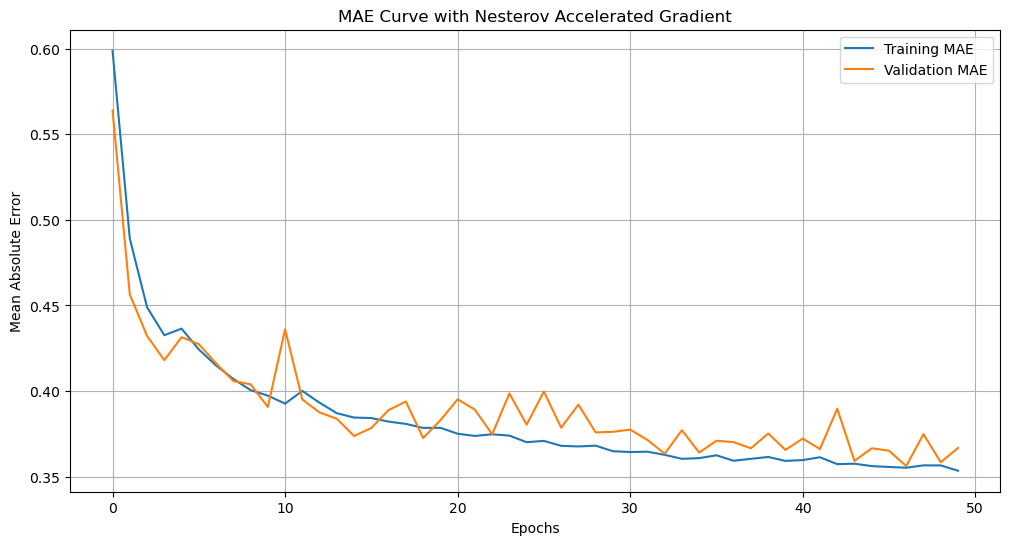

In [42]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.title('MAE Curve with Nesterov Accelerated Gradient')
plt.legend()
plt.grid(True)
plt.show()
